I want to compute statistical significance of context_variants for BC detection. But just trying to show with venn-diagram representation.

In [3]:
!pip install matplotlib-venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45389 sha256=476901c4775f221e4e9d0e8ee62542e1b6a51b2adab9b9cb6a4dfb5659114951
  Stored in directory: /Users/rachnaraj/Library/Caches/pip/wheels/c4/16/4a/93374cd955bbe0553a8ce74db7f0fbd5fcc876e19fb78bd601
Successfully built matplotlib-venn



GPT-4o:
  Minimal only        : 2
  Method only         : 0
  Class only          : 9
  Minimal & Method    : 0
  Minimal & Class     : 5
  Method  & Class     : 3
  All three           : 10
  None                : 60
  Total BUMP          : 89

Qwen-480B:
  Minimal only        : 3
  Method only         : 4
  Class only          : 4
  Minimal & Method    : 1
  Minimal & Class     : 1
  Method  & Class     : 2
  All three           : 13
  None                : 61
  Total BUMP          : 89

GPT-OSS-120b:
  Minimal only        : 1
  Method only         : 0
  Class only          : 2
  Minimal & Method    : 0
  Minimal & Class     : 0
  Method  & Class     : 5
  All three           : 3
  None                : 78
  Total BUMP          : 89

Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.pdf
Saved → /Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures/venn_context_detection.png


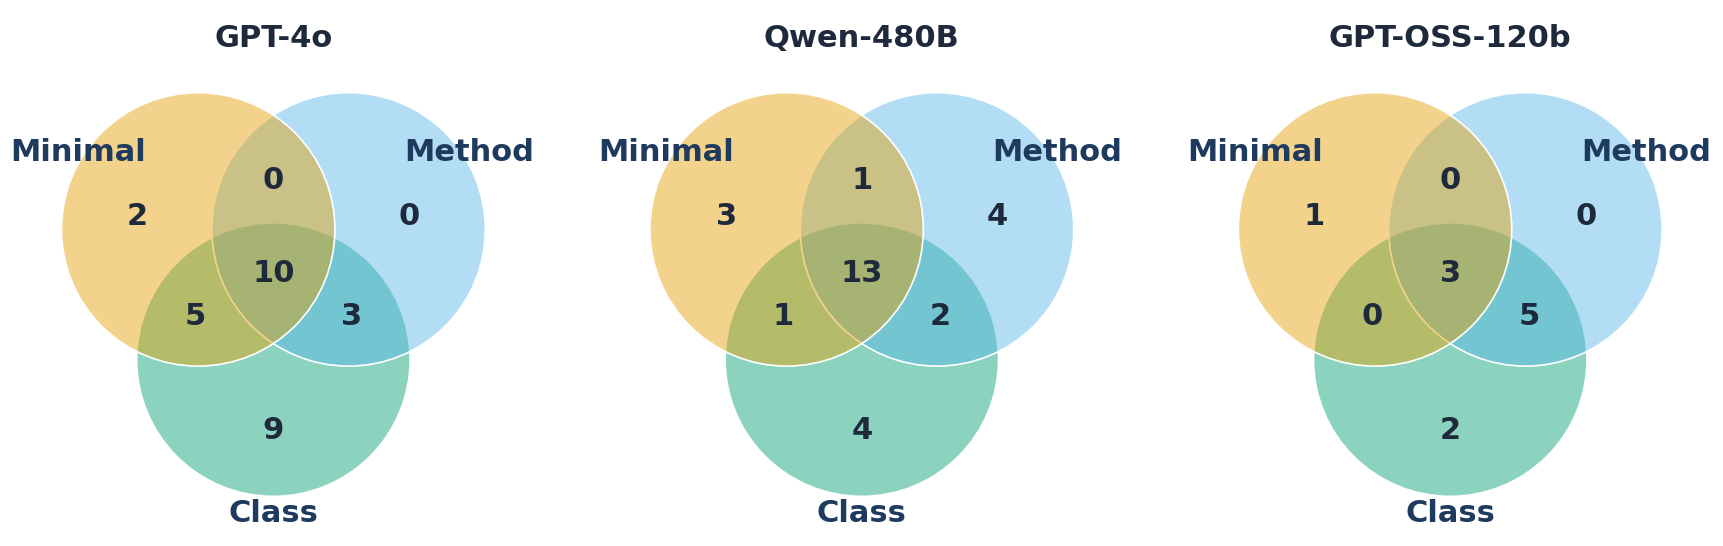

In [6]:
"""
venn_context_detection.py
==========================
Generates one 3-way Venn diagram per model showing which instances
are detected by Minimal, Method, and/or Class context variants.
Uses perfectly equal fixed-size circles with actual counts as labels.
No matplotlib-venn needed.
"""

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DETECTED_CSV = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/detected_bc_errortype_coverage.csv"
BUMP_CSV     = "/Volumes/Rachna-HD/ConfigFiles/Candidate_BUMP_Instance_errorTypes_with_categories_v2.csv"
OUTPUT_DIR   = "/Volumes/Rachna-HD/RQResultsForPaper/RQ2/figures"

MODEL_ORDER   = ['GPT-4o', 'Qwen-480B', 'GPT-OSS-120b']
VARIANT_ORDER = ['Minimal', 'Method', 'Class']

# Wong colorblind-safe palette
COLORS = {
    'Minimal': '#E69F00',
    'Method':  '#56B4E9',
    'Class':   '#009E73',
}
# ──────────────────────────────────────────────────────────────────────────────

# ── Geometry ──────────────────────────────────────────────────────────────────
RADIUS = 0.40
OFFSET = 0.22

CENTERS = {
    'Minimal': (-OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Method':  (+OFFSET,  OFFSET * math.tan(math.radians(30))),
    'Class':   ( 0.0,    -OFFSET / math.cos(math.radians(30))),
}

_s = OFFSET * 0.95
REGION_POS = {
    '100': (-_s * 1.9,  _s * 0.8),
    '010': (+_s * 1.9,  _s * 0.8),
    '001': ( 0.0,      -_s * 2.2),
    '110': ( 0.0,       _s * 1.3),
    '101': (-_s * 1.1, -_s * 0.6),
    '011': (+_s * 1.1, -_s * 0.6),
    '111': ( 0.0,       0.0),
}

SET_LABEL_POS = {
    'Minimal': (-OFFSET * 2.6,  OFFSET * 1.6),
    'Method':  (+OFFSET * 2.6,  OFFSET * 1.6),
    'Class':   ( 0.0,          -OFFSET * 3.2),
}
# ─────────────────────────────────────────────────────────────────────────────


def load_data(detected_csv, bump_csv):
    df = pd.read_csv(detected_csv, sep=None, engine='python',
                     dtype=str, keep_default_na=False)
    df['custom_id']       = df['custom_id'].str.strip()
    df['model']           = df['model'].str.strip()
    df['context_variant'] = df['context_variant'].str.strip()

    bump_df = pd.read_csv(bump_csv, sep=None, engine='python',
                          dtype=str, keep_default_na=False)
    all_ids = set(bump_df['custom_id'].str.strip().unique())
    return df, all_ids


def get_detected_sets(df, model):
    mdf = df[df['model'] == model]
    return {v: set(mdf[mdf['context_variant'] == v]['custom_id'].unique())
            for v in VARIANT_ORDER}


def plot_venn(model, sets, all_ids, ax):
    A, B, C = sets['Minimal'], sets['Method'], sets['Class']

    only_A  = A - B - C
    only_B  = B - A - C
    only_C  = C - A - B
    AB_only = (A & B) - C
    AC_only = (A & C) - B
    BC_only = (B & C) - A
    ABC     = A & B & C
    none    = all_ids - A - B - C

    region_counts = {
        '100': len(only_A),
        '010': len(only_B),
        '001': len(only_C),
        '110': len(AB_only),
        '101': len(AC_only),
        '011': len(BC_only),
        '111': len(ABC),
    }

    # ── Draw filled circles (back → front) ───────────────────────────────
    for variant in ['Class', 'Method', 'Minimal']:
        cx, cy = CENTERS[variant]
        ax.add_patch(mpatches.Circle(
            (cx, cy), RADIUS,
            facecolor=to_rgba(COLORS[variant], alpha=0.45),
            edgecolor='white',
            linewidth=1.2,
            zorder=2,
        ))

    # ── Region count labels ───────────────────────────────────────────────
    for rid, (rx, ry) in REGION_POS.items():
        ax.text(rx, ry, str(region_counts[rid]),
                ha='center', va='center',
                fontsize=22, fontweight='bold', color='#1e293b',
                zorder=3)

    # ── Set name labels ───────────────────────────────────────────────────
    for variant, (lx, ly) in SET_LABEL_POS.items():
        ax.text(lx, ly, variant,
                ha='center', va='center',
                fontsize=22, fontweight='bold', color='#1e3a5f',
                zorder=3)

    # ── Axes limits (must be set before ax.text using lim) ───────────────
    lim = RADIUS + OFFSET + 0.15
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Model name inside top of axes ────────────────────────────────────
    ax.text(0, lim - 0.04, model,
            ha='center', va='top',
            fontsize=22, fontweight='bold', color='#1e293b',
            zorder=4)

    # Console breakdown
    print(f"\n{model}:")
    print(f"  Minimal only        : {len(only_A)}")
    print(f"  Method only         : {len(only_B)}")
    print(f"  Class only          : {len(only_C)}")
    print(f"  Minimal & Method    : {len(AB_only)}")
    print(f"  Minimal & Class     : {len(AC_only)}")
    print(f"  Method  & Class     : {len(BC_only)}")
    print(f"  All three           : {len(ABC)}")
    print(f"  None                : {len(none)}")
    print(f"  Total BUMP          : {len(all_ids)}")


def main():
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    df, all_ids = load_data(DETECTED_CSV, BUMP_CSV)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, model in zip(axes, MODEL_ORDER):
        sets = get_detected_sets(df, model)
        plot_venn(model, sets, all_ids, ax)

    plt.tight_layout(pad=2.5)

    out_pdf = out_dir / "venn_context_detection.pdf"
    out_png = out_dir / "venn_context_detection.png"
    fig.savefig(out_pdf, bbox_inches='tight', dpi=300)
    fig.savefig(out_png, bbox_inches='tight', dpi=300)
    print(f"\nSaved → {out_pdf}")
    print(f"Saved → {out_png}")
    plt.show()


if __name__ == "__main__":
    main()

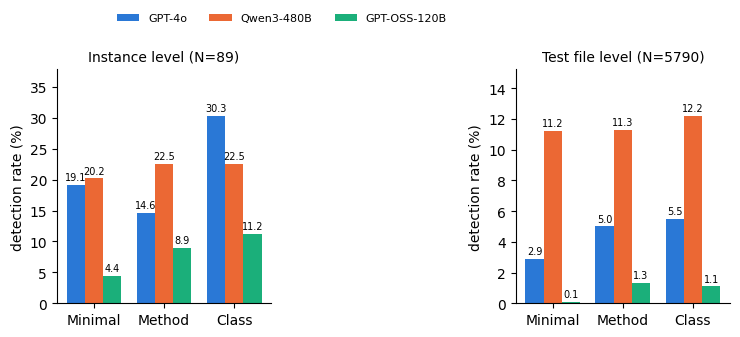

In [1]:
import matplotlib.pyplot as plt
import numpy as np

contexts = ["Minimal", "Method", "Class"]
models = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
# detection rate (%) per level, rows = models, cols = contexts
rates = {
    "Instance level (N=89)":    [[19.1, 14.6, 30.3], [20.2, 22.5, 22.5], [4.4, 8.9, 11.2]],
    "Test file level (N=5790)": [[2.9, 5.0, 5.5],    [11.2, 11.3, 12.2], [0.1, 1.3, 1.1]],
}
colors = ["#2a78d6", "#eb6834", "#1baf7a"]   # Cove order, one per model
x = np.arange(len(contexts)); w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
for ax, (title, mat) in zip(axes, rates.items()):
    for i, (m, c) in enumerate(zip(models, colors)):
        bars = ax.bar(x + (i - 1) * w, mat[i], w, color=c, label=m)
        ax.bar_label(bars, fmt="%.1f", fontsize=7, padding=2)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel("detection rate (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, max(max(r) for r in mat) * 1.25)

axes[0].legend(frameon=False, fontsize=8, ncol=3,
               loc="upper center", bbox_to_anchor=(1.05, 1.28))
plt.tight_layout(); plt.savefig("rq2_grouped_bars.pdf", bbox_inches="tight")

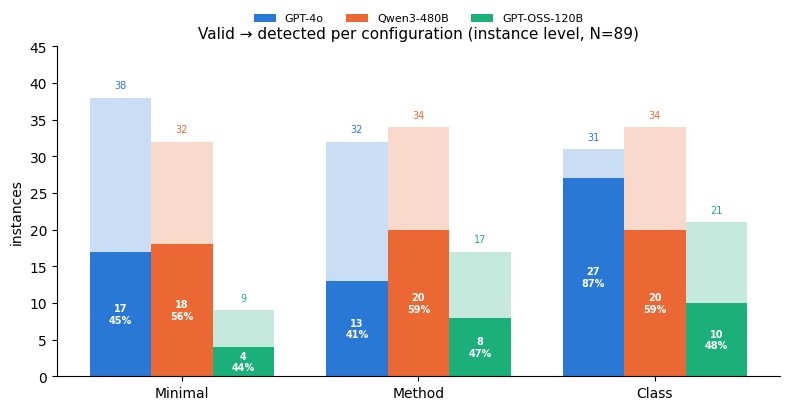

In [2]:
import matplotlib.pyplot as plt
import numpy as np

contexts = ["Minimal", "Method", "Class"]
models = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
N = 89
# (valid, detected) per model x context
valid = {"GPT-4o":[38,32,31], "Qwen3-480B":[32,34,34], "GPT-OSS-120B":[9,17,21]}
det   = {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]}
colors = ["#2a78d6", "#eb6834", "#1baf7a"]
x = np.arange(len(contexts)); w = 0.26

fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (m, c) in enumerate(zip(models, colors)):
    xpos = x + (i-1)*w
    v, d = np.array(valid[m]), np.array(det[m])
    # pale bar = valid (survived pre-breaking), solid = detected (survived breaking)
    ax.bar(xpos, v, w, color=c, alpha=0.25)
    bars = ax.bar(xpos, d, w, color=c, label=m)
    for xp, dv, vv in zip(xpos, d, v):
        ax.text(xp, dv/2, f"{dv}\n{dv/vv*100:.0f}%", ha="center", va="center",
                fontsize=7, color="white", fontweight="bold")   # detected count + yield inside
        ax.text(xp, vv+1, f"{vv}", ha="center", va="bottom",
                fontsize=7, color=c)                              # valid count above pale bar

ax.set_xticks(x); ax.set_xticklabels(contexts)
ax.set_ylabel("instances"); ax.set_ylim(0, 45)
ax.set_title("Valid \u2192 detected per configuration (instance level, N=89)", fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.13))
plt.tight_layout(); plt.savefig("rq2_funnel.pdf", bbox_inches="tight")

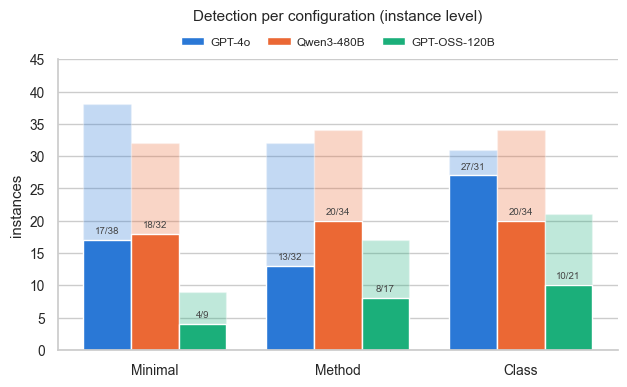

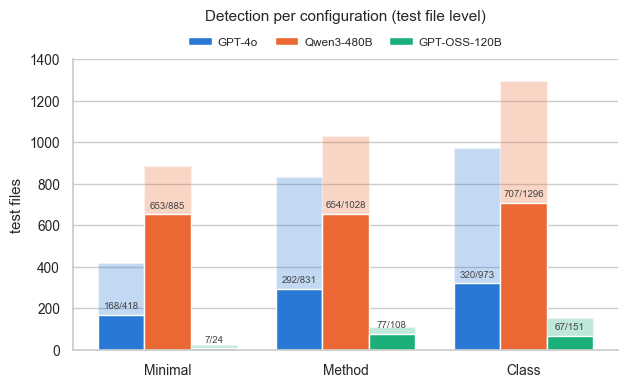

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)

models   = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors   = {"GPT-4o": "#2a78d6", "Qwen3-480B": "#eb6834", "GPT-OSS-120B": "#1baf7a"}
contexts = ["Minimal", "Method", "Class"]

def grouped(valid, det, fname, title, ylabel, ymax):
    x = np.arange(len(contexts)); w = 0.26
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    for i, m in enumerate(models):
        xp = x + (i - 1) * w
        v = [valid[m][j] for j in range(3)]
        d = [det[m][j]   for j in range(3)]
        ax.bar(xp, v, w, color=colors[m], alpha=0.28)          # valid (pale)
        ax.bar(xp, d, w, color=colors[m], label=m)             # detected (dark)
        for xx, dd, vv in zip(xp, d, v):
            ax.text(xx, dd + ymax*0.015, f"{dd}/{vv}",
                    ha="center", va="bottom", fontsize=7, color="#444")

    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel(ylabel); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=11, pad=28)
    ax.grid(axis="x", visible=False)          # no vertical lines
    sns.despine()
    ax.legend(frameon=False, fontsize=8.5, ncol=3,
              loc="lower center", bbox_to_anchor=(0.5, 1.005),
              handletextpad=0.5, columnspacing=1.4)
    plt.tight_layout(); plt.savefig(fname, bbox_inches="tight")

# instance level
grouped({"GPT-4o":[38,32,31], "Qwen3-480B":[32,34,34], "GPT-OSS-120B":[9,17,21]},
        {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]},
        "rq2_instance.pdf", "Detection per configuration (instance level)",
        "instances", 45)

# test file level  (y-max scaled to valid counts, not 5790)
grouped({"GPT-4o":[418,831,973], "Qwen3-480B":[885,1028,1296], "GPT-OSS-120B":[24,108,151]},
        {"GPT-4o":[168,292,320], "Qwen3-480B":[653,654,707],   "GPT-OSS-120B":[7,77,67]},
        "rq2_file.pdf", "Detection per configuration (test file level)",
        "test files", 1400)

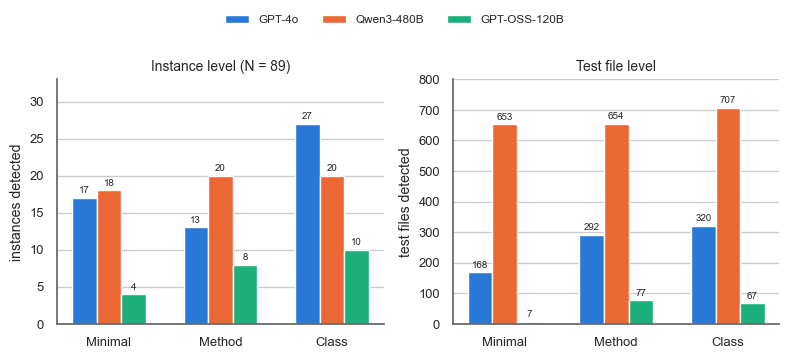

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.85)
plt.rcParams["axes.edgecolor"] = "#666"

models   = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors   = {"GPT-4o": "#2a78d6", "Qwen3-480B": "#eb6834", "GPT-OSS-120B": "#1baf7a"}
contexts = ["Minimal", "Method", "Class"]

det_inst = {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]}
det_file = {"GPT-4o":[168,292,320], "Qwen3-480B":[653,654,707], "GPT-OSS-120B":[7,77,67]}

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
x = np.arange(len(contexts)); w = 0.22

def panel(ax, data, title, ylabel, ymax):
    for i, m in enumerate(models):
        xp = x + (i - 1) * w
        bars = ax.bar(xp, data[m], w, color=colors[m], label=m)
        ax.bar_label(bars, fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel(ylabel); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)

panel(axes[0], det_inst, "Instance level (N = 89)", "instances detected", 33)
panel(axes[1], det_file, "Test file level",          "test files detected", 800)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("rq2_detection.pdf", bbox_inches="tight")

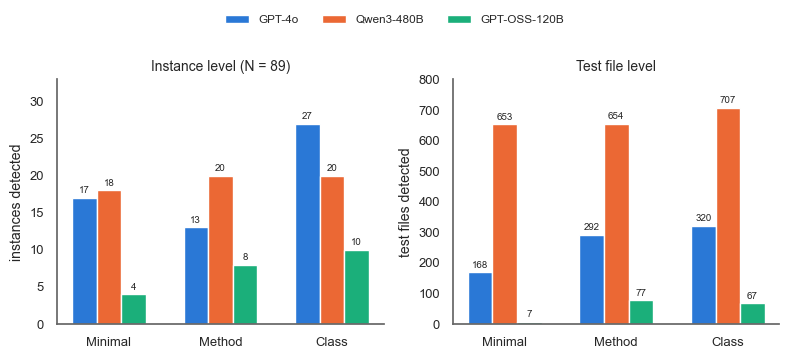

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.85)
plt.rcParams["axes.edgecolor"] = "#666"

models   = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors   = {"GPT-4o": "#2a78d6", "Qwen3-480B": "#eb6834", "GPT-OSS-120B": "#1baf7a"}
contexts = ["Minimal", "Method", "Class"]

det_inst = {"GPT-4o":[17,13,27], "Qwen3-480B":[18,20,20], "GPT-OSS-120B":[4,8,10]}
det_file = {"GPT-4o":[168,292,320], "Qwen3-480B":[653,654,707], "GPT-OSS-120B":[7,77,67]}

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
x = np.arange(len(contexts)); w = 0.22

def panel(ax, data, title, ylabel, ymax):
    for i, m in enumerate(models):
        xp = x + (i - 1) * w
        bars = ax.bar(xp, data[m], w, color=colors[m], label=m)
        ax.bar_label(bars, fontsize=7, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(contexts)
    ax.set_ylabel(ylabel); ax.set_ylim(0, ymax)
    ax.set_title(title, fontsize=10)
    ax.grid(False)                    # remove all gridlines
    sns.despine(ax=ax)

panel(axes[0], det_inst, "Instance level (N = 89)", "instances detected", 33)
panel(axes[1], det_file, "Test file level",          "test files detected", 800)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("rq2_detection.pdf", bbox_inches="tight")

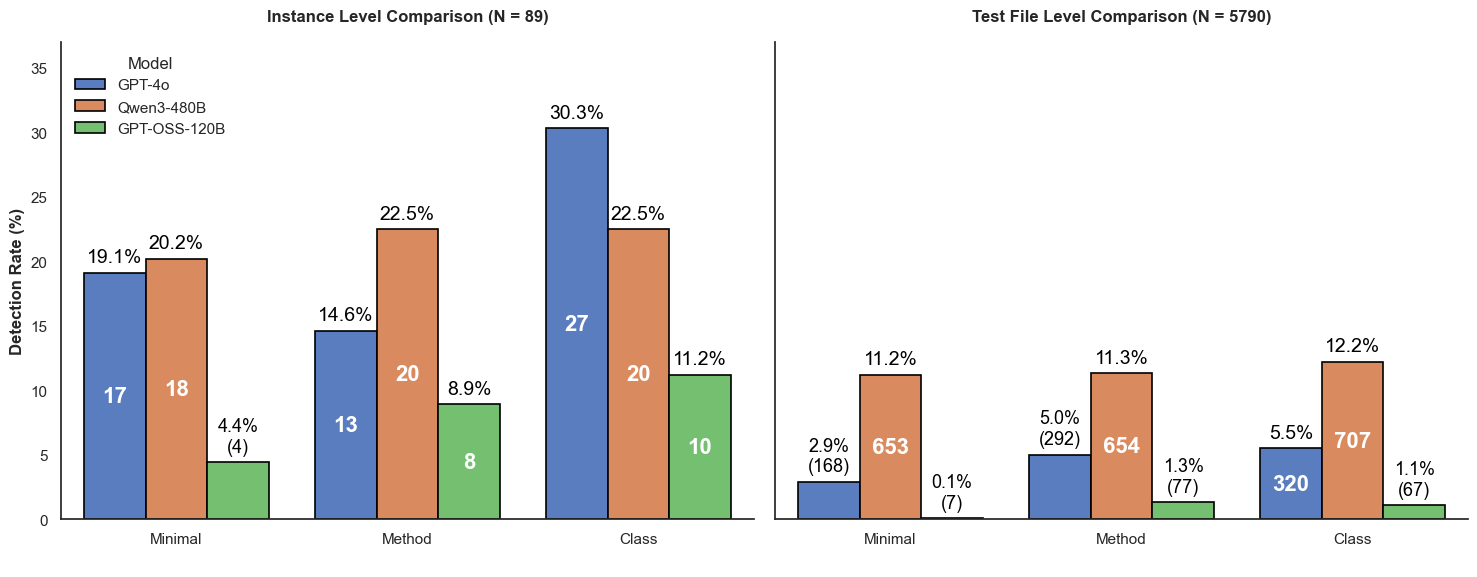

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    # Detection Rates (%)
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    # Raw Detected Counts (#)
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
# Changed to "white" to remove horizontal gridlines
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 14, 'pdf.fonttype': 42})

# Create a figure with 2 side-by-side subplots sharing the same Y-axis
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.2
)

axes[0].set_title('Instance Level Comparison (N = 89)', fontweight='bold', pad=15)
axes[0].set_xlabel('', fontweight='bold')
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold')
# Increased y-limit slightly to give room for the top text
axes[0].set_ylim(0, 37) 

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=16)
        else:
            # Stacked neatly above if the bar is too short
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.2
)

axes[1].set_title('Test File Level Comparison (N = 5790)', fontweight='bold', pad=15)
axes[1].set_xlabel(' ', fontweight='bold')
axes[1].set_ylabel('') # Clear y-label since it is shared

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=16)
        else:
            # Stacked neatly above if the bar is too short
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
axes[0].legend(title='Model', loc='upper left', frameon=False)
axes[1].get_legend().remove()

# Removes the top and right chart borders for a cleaner, modern look
sns.despine()

plt.tight_layout()
plt.show()

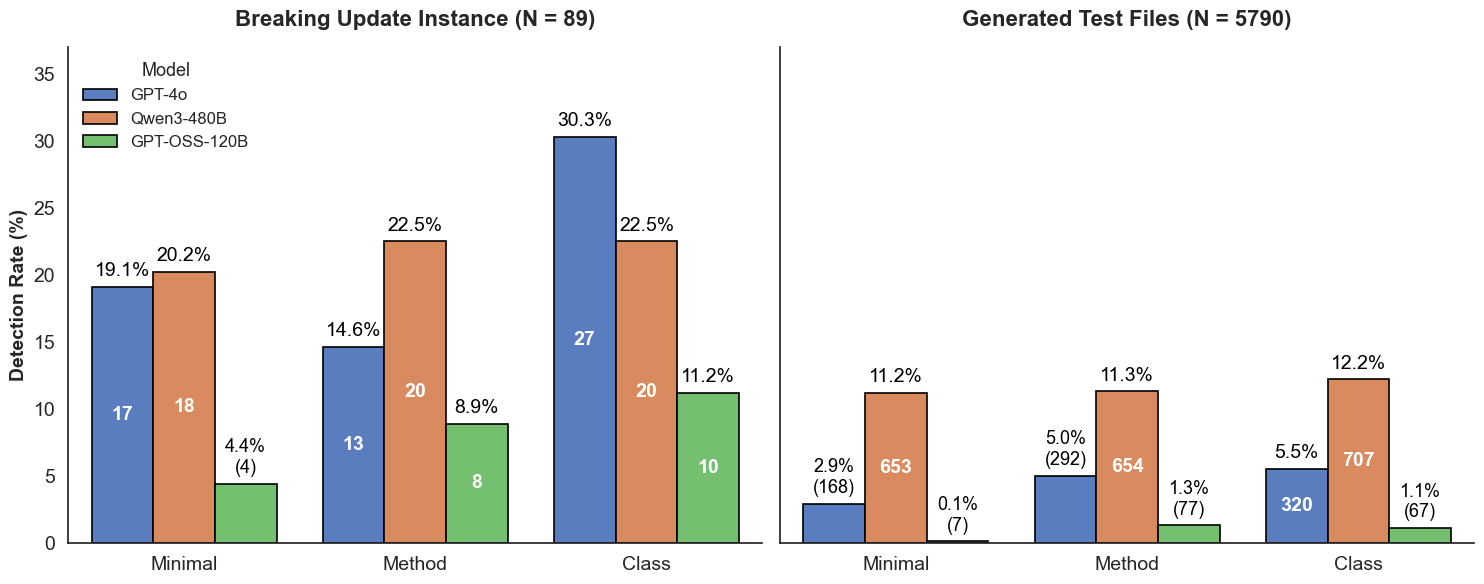

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    # Detection Rates (%)
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    # Raw Detected Counts (#)
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
# Changed to "white" to remove horizontal gridlines
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 12, 'pdf.fonttype': 42})

# Create a figure with 2 side-by-side subplots sharing the same Y-axis
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.2
)

axes[0].set_title('Breaking Update Instance (N = 89)', fontweight='bold', pad=15, fontsize=16)
axes[0].set_xlabel('', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=14)
axes[0].set_ylim(0, 37) 

# Increase font size for axis tick labels (Minimal, Method, Class, and Y-axis numbers)
axes[0].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.2
)

axes[1].set_title('Generated Test Files (N = 5790)', fontweight='bold', pad=15, fontsize=16)
axes[1].set_xlabel('', fontweight='bold', fontsize=14)
axes[1].set_ylabel('') # Clear y-label since it is shared

# Increase font size for axis tick labels
axes[1].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
# Increased legend font size to match the new styling
axes[0].legend(title='Model', loc='upper left', frameon=False, fontsize=12, title_fontsize=13)
axes[1].get_legend().remove()

# Removes the top and right chart borders for a cleaner, modern look
sns.despine()

plt.tight_layout()
plt.show()

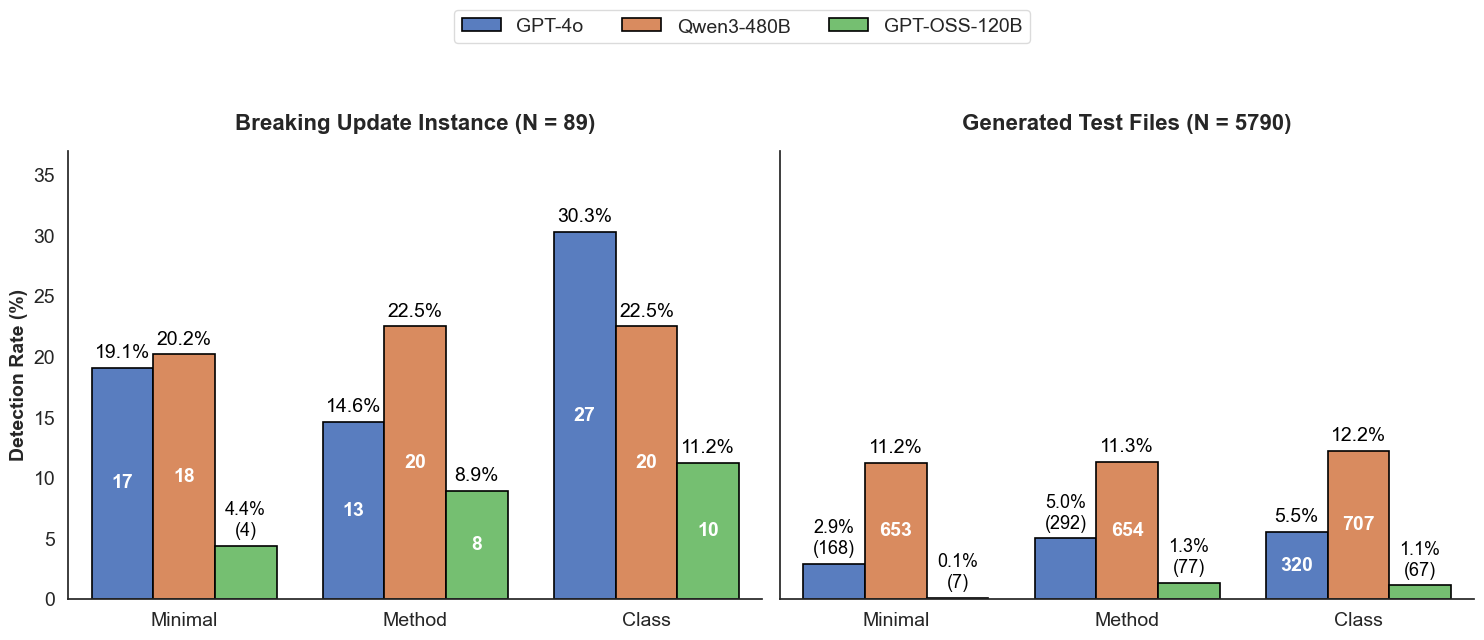

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    # Detection Rates (%)
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    # Raw Detected Counts (#)
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
# Changed to "white" to remove horizontal gridlines
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 12, 'pdf.fonttype': 42})

# Create a figure with 2 side-by-side subplots sharing the same Y-axis
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.2
)

axes[0].set_title('Breaking Update Instance (N = 89)', fontweight='bold', pad=15, fontsize=16)
axes[0].set_xlabel('', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=14)
axes[0].set_ylim(0, 37) 

# Increase font size for axis tick labels (Minimal, Method, Class, and Y-axis numbers)
axes[0].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.2
)

axes[1].set_title('Generated Test Files (N = 5790)', fontweight='bold', pad=15, fontsize=16)
axes[1].set_xlabel('', fontweight='bold', fontsize=14)
axes[1].set_ylabel('') # Clear y-label since it is shared

# Increase font size for axis tick labels
axes[1].tick_params(axis='both', labelsize=14)

# Add Labels: Slice patches to strictly match DataFrame length
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            # Percentage on top
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=14)
            # Raw Count inside
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=14)
        else:
            # Stacked neatly above if the bar is too short
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=13)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
# 1. Extract the legend handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# 2. Remove the individual subplot legends created by Seaborn
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# 3. Create a single, centered figure-level legend at the top
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
           ncol=3, fontsize=14, frameon=True, edgecolor='lightgrey')

# Removes the top and right chart borders for a cleaner, modern look
sns.despine()

# Use 'rect' to scale the subplots down slightly so the top legend fits
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

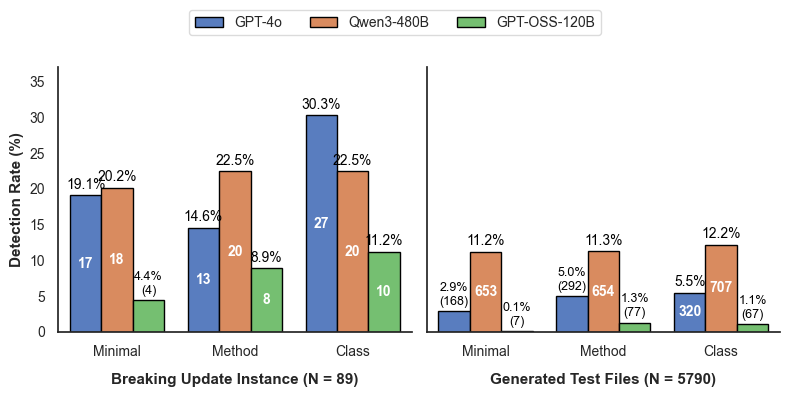

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 10, 'pdf.fonttype': 42})

# Create a much more compact figure suitable for a single column
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label to save vertical space
axes[0].set_xlabel('Breaking Update Instance (N = 89)', fontweight='bold', fontsize=11, labelpad=10)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 37) 
axes[0].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label
axes[1].set_xlabel('Generated Test Files (N = 5790)', fontweight='bold', fontsize=11, labelpad=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------
# Extract legend handles
handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# Create top shared legend, tighter to the plot
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=3, fontsize=10, frameon=True, edgecolor='lightgrey')

sns.despine()

# Adjust 'rect' to leave just enough room for the legend on top
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

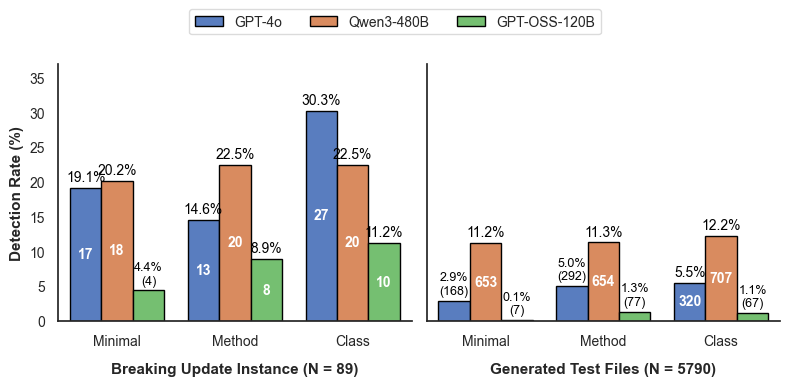

In [40]:
import matplotlib.pyplot as plt
import seaborn as pd
import pandas as pd
import seaborn as sns

# 1. Prepare the Data 
data = {
    'Model': [
        'GPT-4o', 'GPT-4o', 'GPT-4o',
        'Qwen3-480B', 'Qwen3-480B', 'Qwen3-480B',
        'GPT-OSS-120B', 'GPT-OSS-120B', 'GPT-OSS-120B'
    ],
    'Context': [
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class',
        'Minimal', 'Method', 'Class'
    ],
    'Instance_Det_Rate': [19.1, 14.6, 30.3, 20.2, 22.5, 22.5, 4.4, 8.9, 11.2],
    'TestFile_Det_Rate': [2.9, 5.0, 5.5, 11.2, 11.3, 12.2, 0.1, 1.3, 1.1],
    'Instance_Count': [17, 13, 27, 18, 20, 20, 4, 8, 10],
    'TestFile_Count': [168, 292, 320, 653, 654, 707, 7, 77, 67]
}

df = pd.DataFrame(data)

# 2. Set up the plotting style
sns.set_theme(style="white")
plt.rcParams.update({'font.size': 10, 'pdf.fonttype': 42})

# Create a much more compact figure suitable for a single column
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8), sharey=True)

# ---------------------------------------------------
# Left Panel: Instance Level (N = 89)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='Instance_Det_Rate', hue='Model', 
    ax=axes[0], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label to save vertical space
axes[0].set_xlabel('Breaking Update Instance (N = 89)', fontweight='bold', fontsize=11, labelpad=10)
axes[0].set_ylabel('Detection Rate (%)', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 37) 
axes[0].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[0].patches[:len(df)]):
    height = p.get_height()
    count = df['Instance_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[0].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Right Panel: Test File Level (N = 5790)
# ---------------------------------------------------
sns.barplot(
    data=df, x='Context', y='TestFile_Det_Rate', hue='Model', 
    ax=axes[1], palette='muted', edgecolor='black', linewidth=1.0
)

# Move the title to the x-axis label
axes[1].set_xlabel('Generated Test Files (N = 5790)', fontweight='bold', fontsize=11, labelpad=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=10)

# Add Labels
for i, p in enumerate(axes[1].patches[:len(df)]):
    height = p.get_height()
    count = df['TestFile_Count'].iloc[i]
    
    if height > 0:
        if height > 5.0:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%', ha='center', va='bottom', color='black', fontsize=10)
            axes[1].text(p.get_x() + p.get_width()/2., height / 2, 
                         f'{count}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, 
                         f'{height:.1f}%\n({count})', ha='center', va='bottom', color='black', fontsize=9)

# ---------------------------------------------------
# Final Layout Adjustments & Saving
# ---------------------------------------------------
# Extract legend handles
handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# Increase 'rect' top limit to allow the plots to take up more vertical space
plt.tight_layout(rect=[0, 0, 1, 0.90])

# Anchor the bottom ('lower center') of the legend slightly above the plots (y=0.92)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.92), 
           ncol=3, fontsize=10, frameon=True, edgecolor='lightgrey')

# Remove top and right borders
sns.despine()

# Save the figure BEFORE showing it, using bbox_inches='tight' to prevent cropping
plt.savefig('breaking_update_results.pdf', format='pdf', bbox_inches='tight', dpi=300)

# Display the plot
plt.show()